<a href="https://colab.research.google.com/github/Dhanunjay03/NLP/blob/Task-1/Task1__NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import required libraries

In [ ]:
import pandas as pd
import re
import spacy
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# Load Spacy model for NER

In [ ]:
!python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 89.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


# Load dataset

In [ ]:
!git clone https://github.com/KaiDMML/FakeNewsNet.git

Cloning into 'FakeNewsNet'...
remote: Enumerating objects: 759, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 759 (delta 8), reused 2 (delta 2), pack-reused 747 (from 3)
Receiving objects: 100% (759/759), 43.99 MiB | 25.53 MiB/s, done.
Resolving deltas: 100% (155/155), done.


In [ ]:
# File paths
gossipcop_fake_path = "/content/FakeNewsNet/dataset/gossipcop_fake.csv"
gossipcop_real_path = "/content/FakeNewsNet/dataset/gossipcop_real.csv"
politifact_fake_path = "/content/FakeNewsNet/dataset/politifact_fake.csv"
politifact_real_path = "/content/FakeNewsNet/dataset/politifact_real.csv"

# Load data
gossipcop_fake = pd.read_csv(gossipcop_fake_path)
gossipcop_real = pd.read_csv(gossipcop_real_path)
politifact_fake = pd.read_csv(politifact_fake_path)
politifact_real = pd.read_csv(politifact_real_path)


In [ ]:
# Add labels and merge
gossipcop_fake['label'] = 'fake'
gossipcop_real['label'] = 'real'
politifact_fake['label'] = 'fake'
politifact_real['label'] = 'real'

In [ ]:
# Combine all data
news_df = pd.concat([gossipcop_fake, gossipcop_real, politifact_fake, politifact_real], ignore_index=True)

# Display dataset info
print("Dataset Shape:", news_df.shape)
print(news_df.head())

Dataset Shape: (23196, 5)
                     id                                           news_url  \
0  gossipcop-2493749932  www.dailymail.co.uk/tvshowbiz/article-5874213/...   
1  gossipcop-4580247171  hollywoodlife.com/2018/05/05/paris-jackson-car...   
2   gossipcop-941805037  variety.com/2017/biz/news/tax-march-donald-tru...   
3  gossipcop-2547891536  www.dailymail.co.uk/femail/article-3499192/Do-...   
4  gossipcop-5476631226  variety.com/2018/film/news/list-2018-oscar-nom...   

                                               title  \
0  Did Miley Cyrus and Liam Hemsworth secretly ge...   
1  Paris Jackson & Cara Delevingne Enjoy Night Ou...   
2  Celebrities Join Tax March in Protest of Donal...   
3  Cindy Crawford's daughter Kaia Gerber wears a ...   
4      Full List of 2018 Oscar Nominations – Variety   

                                           tweet_ids label  
0  284329075902926848\t284332744559968256\t284335...  fake  
1  992895508267130880\t992897935418503169\t992

In [ ]:
def clean_text(text):
    # Remove special characters, HTML tags, and extra spaces
    text = re.sub(r'<[^>]+>', '', str(text))  # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text)      # Remove special characters
    text = text.lower().strip()             # Convert to lowercase and strip spaces
    return text

news_df['cleaned_title'] = news_df['title'].apply(clean_text)

In [ ]:
print(news_df.head())

                     id                                           news_url  \
0  gossipcop-2493749932  www.dailymail.co.uk/tvshowbiz/article-5874213/...   
1  gossipcop-4580247171  hollywoodlife.com/2018/05/05/paris-jackson-car...   
2   gossipcop-941805037  variety.com/2017/biz/news/tax-march-donald-tru...   
3  gossipcop-2547891536  www.dailymail.co.uk/femail/article-3499192/Do-...   
4  gossipcop-5476631226  variety.com/2018/film/news/list-2018-oscar-nom...   

                                               title  \
0  Did Miley Cyrus and Liam Hemsworth secretly ge...   
1  Paris Jackson & Cara Delevingne Enjoy Night Ou...   
2  Celebrities Join Tax March in Protest of Donal...   
3  Cindy Crawford's daughter Kaia Gerber wears a ...   
4      Full List of 2018 Oscar Nominations – Variety   

                                           tweet_ids label  \
0  284329075902926848\t284332744559968256\t284335...  fake   
1  992895508267130880\t992897935418503169\t992899...  fake   
2  85335

In [ ]:
# Extract entities
def extract_entities(text):
    doc = nlp(text)
    entities = Counter([ent.label_ for ent in doc.ents])
    return entities

news_df['entity_counts'] = news_df['cleaned_title'].apply(extract_entities)

# Split entity counts into separate columns
entity_df = news_df['entity_counts'].apply(pd.Series).fillna(0)
news_df = pd.concat([news_df, entity_df], axis=1)

In [ ]:
# Compute popularity score
news_df['popularity_score'] = news_df['tweet_ids'].apply(lambda x: len(str(x).split('\t')) if pd.notnull(x) else 0)

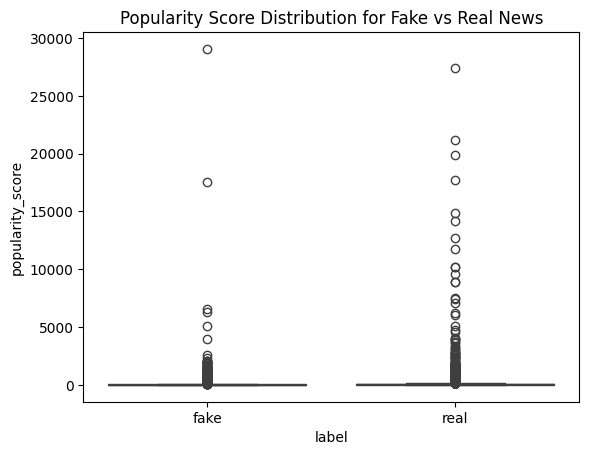

In [ ]:
# Popularity score distribution
sns.boxplot(data=news_df, x='label', y='popularity_score')
plt.title("Popularity Score Distribution for Fake vs Real News")
plt.show()

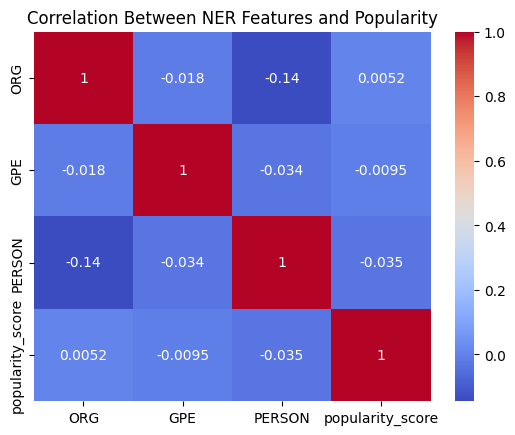

In [ ]:
# Correlation heatmap
correlation_matrix = news_df[['ORG', 'GPE', 'PERSON', 'popularity_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between NER Features and Popularity")
plt.show()

In [ ]:
# Prepare features and labels
X = news_df[['ORG', 'GPE', 'PERSON', 'popularity_score']].fillna(0)
y = news_df['label'].apply(lambda x: 1 if x == 'real' else 0)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8088362068965518
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.45      0.54      1148
           1       0.84      0.93      0.88      3492

    accuracy                           0.81      4640
   macro avg       0.75      0.69      0.71      4640
weighted avg       0.80      0.81      0.79      4640



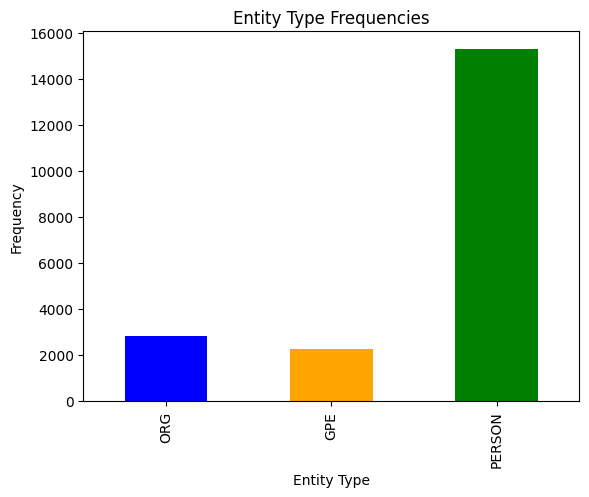

In [ ]:
# Visualize entity frequencies
entity_freq = news_df[['ORG', 'GPE', 'PERSON']].sum()
entity_freq.plot(kind='bar', color=['blue', 'orange', 'green'])
plt.title("Entity Type Frequencies")
plt.xlabel("Entity Type")
plt.ylabel("Frequency")
plt.show()